# **IMPORT LIBRARY**

In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
from PIL import Image
from collections import Counter
import random
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import matplotlib.pyplot as plt
from datasets import load_dataset


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models

# **LOAD DATASET**

In [2]:
path = kagglehub.dataset_download("eeshawn/flickr30k")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\LENOVO\.cache\kagglehub\datasets\eeshawn\flickr30k\versions\1


In [3]:
captions_path = os.path.join(path, "captions.txt")
images_path = os.path.join(path, "flickr30k_images")

df = pd.read_csv(captions_path)

print(df.head())
print(df.columns)

       image_name  comment_number  \
0  1000092795.jpg               0   
1  1000092795.jpg               1   
2  1000092795.jpg               2   
3  1000092795.jpg               3   
4  1000092795.jpg               4   

                                             comment  
0  Two young guys with shaggy hair look at their ...  
1  Two young  White males are outside near many b...  
2   Two men in green shirts are standing in a yard .  
3       A man in a blue shirt standing in a garden .  
4            Two friends enjoy time spent together .  
Index(['image_name', 'comment_number', 'comment'], dtype='object')


In [4]:
image_caption_dict = {}

for _, row in df.iterrows():
    img = row['image_name']
    cap = row['comment']

    if img not in image_caption_dict:
        image_caption_dict[img] = []

    image_caption_dict[img].append(cap)

print("Total images:", len(image_caption_dict))

Total images: 31783


# **Build Vocabulary**

In [ ]:
def tokenize(text):
    return text.lower().split()

counter = Counter()

for caps in image_caption_dict.values():
    for cap in caps:
        counter.update(tokenize(cap))

vocab = {word: idx+4 for idx, (word, _) in enumerate(counter.items())}

vocab["<PAD>"] = 0
vocab["<SOS>"] = 1
vocab["<EOS>"] = 2
vocab["<UNK>"] = 3

inv_vocab = {idx: word for word, idx in vocab.items()}
vocab_size = len(vocab)

print("Vocab size:", vocab_size)

Vocab size: 20324


In [81]:
import pickle

# Gom cả 2 biến từ điển vào 1 gói (dictionary) để dễ lưu trữ
vocab_data = {
    'vocab': vocab,
    'inv_vocab': inv_vocab
}

# Lưu gói dữ liệu này ra một file có tên là 'vocab.pkl'
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab_data, f)

print("✅ Đã lưu thành công file vocab.pkl!")

✅ Đã lưu thành công file vocab.pkl!


In [6]:
MAX_LEN = 20

def encode(text):
    tokens = tokenize(text)
    seq = [vocab.get(w, vocab["<UNK>"]) for w in tokens]
    seq = [vocab["<SOS>"]] + seq + [vocab["<EOS>"]]

    if len(seq) < MAX_LEN:
        seq += [vocab["<PAD>"]] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]

    return torch.tensor(seq)

# **Generate multiple questions**

In [7]:
def generate_questions(caption):
    caption = caption.lower()
    questions = []

    questions.append("what is in the image")
    questions.append("what is happening in the image")

    if "man" in caption:
        questions.append("who is in the image")
        questions.append("what is the man doing")

    if "woman" in caption:
        questions.append("who is in the image")
        questions.append("what is the woman doing")

    if "people" in caption:
        questions.append("who are in the image")

    if "park" in caption:
        questions.append("where is this happening")

    if "street" in caption:
        questions.append("where is the scene")

    if "two" in caption or "three" in caption:
        questions.append("how many people are there")


    if "red" in caption:
        questions.append("what color is the object")

    if "dog" in caption:
        questions.append("is there a dog in the image")

    return list(set(questions))

# **IMAGE PREPROCESSING**

In [42]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# **DATA LOADER**

In [9]:
class VQADataset(Dataset):
    def __init__(self, image_dir, data_dict):
        self.samples = []

        for img, captions in data_dict.items():
            for cap in captions:
                questions = generate_questions(cap)
                for q in questions:
                    self.samples.append((img, q, cap))

        self.image_dir = image_dir

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_name, question, caption = self.samples[idx]

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        image = transform(image)

        return image, encode(question), encode(caption)

In [10]:
from torch.utils.data import random_split

small_dict = dict(list(image_caption_dict.items())[:3000])
dataset = VQADataset(images_path, small_dict)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"Tổng số samples: {len(dataset)}")
print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

Tổng số samples: 51266
Train samples: 41012 | Val samples: 10254


# **GENERAL FUNCTION**

In [36]:
class QuestionEncoder(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 300)
        self.lstm = nn.LSTM(300, 512, batch_first=True)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return h[-1]

In [49]:
def train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs, vocab_size, device, save_name="best_model.pth", patience=3): 
    best_loss = float("inf")
    history = {'train_loss': [], 'val_loss': []}
    scaler = torch.amp.GradScaler('cuda')
    epochs_no_improve = 0 

    for epoch in range(epochs):
        print(f"\n Epoch {epoch+1}/{epochs}")

        # TRAIN PHASE
        model.train()
        total_train_loss = 0
        for img, ques, ans in tqdm(train_loader, desc="Training"):
            img, ques, ans = img.to(device), ques.to(device), ans.to(device)

            optimizer.zero_grad()
            
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                output = model(img, ques, ans[:, :-1])
                loss = criterion(
                    output.reshape(-1, vocab_size),
                    ans[:, 1:].reshape(-1)
            )
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer) 
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            scaler.step(optimizer)
            scaler.update()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # VALIDATION PHASE
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for img, ques, ans in tqdm(val_loader, desc="Validation"):
                img, ques, ans = img.to(device), ques.to(device), ans.to(device)

                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    output = model(img, ques, ans[:, :-1])
                    loss = criterion(
                        output.reshape(-1, vocab_size),
                        ans[:, 1:].reshape(-1)
                    )
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)

        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # SAVE BEST MODEL & EARLY STOPPING
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            epochs_no_improve = 0 
            torch.save(model.state_dict(), save_name)
            print(f"✅ Saved best model to {save_name}")
        else:
            epochs_no_improve += 1
            print(f"Val Loss does not decrease. Patience: {epochs_no_improve}/{patience}")
            
            if epochs_no_improve >= patience: 
                print("EARLY STOPPING ACTIVATED: The model has stopped progressing. Stop training to save time!")
                break 

    return model, history

In [38]:
def decode_sequence(seq, inv_vocab):
    words = []
    for idx in seq:
        word = inv_vocab.get(idx.item(), "")
        if word == "<EOS>":
            break
        if word not in ["<PAD>", "<SOS>"]:
            words.append(word)
    return " ".join(words)

In [39]:
def generate_answer(model, img, ques, vocab, inv_vocab, device, max_len=20):
    model.eval()

    img = img.unsqueeze(0).to(device)
    ques = ques.unsqueeze(0).to(device)

    input_seq = torch.tensor([[vocab["<SOS>"]]]).to(device)
    outputs = []

    for _ in range(max_len):
        with torch.no_grad():
            out = model(img, ques, input_seq)

        next_token = out[:, -1, :].argmax(-1)
        token = next_token.item()

        if token == vocab["<EOS>"]:
            break

        outputs.append(token)
        input_seq = torch.cat([input_seq, next_token.unsqueeze(0)], dim=1)

    return decode_sequence(torch.tensor(outputs), inv_vocab)

In [40]:
def show_prediction(model, dataset, index, vocab, inv_vocab, device):
    img, ques, ans = dataset[index]

    pred_sentence = generate_answer(model, img, ques, vocab, inv_vocab, device)
    true_sentence = decode_sequence(ans, inv_vocab)
    question_text = decode_sequence(ques, inv_vocab)

    img_display = img.permute(1, 2, 0).cpu().numpy()

    plt.imshow(img_display)
    plt.axis("off")
    plt.title(f"Q: {question_text}\nTrue: {true_sentence}\nPred: {pred_sentence}", fontsize=10, loc='left')
    plt.show()

In [41]:
def evaluate_bleu_score(model, test_dataset, vocab, inv_vocab, device, n_samples=100):
    bleu_scores = []
    smooth = SmoothingFunction().method1

    n_samples = min(n_samples, len(test_dataset))

    for _ in tqdm(range(n_samples), desc="Calculating BLEU"):
        idx = random.randint(0, len(test_dataset) - 1)
        img, ques, ans = test_dataset[idx]

        pred_sentence = generate_answer(model, img, ques, vocab, inv_vocab, device)
        true_sentence = decode_sequence(ans, inv_vocab)

        ref = [true_sentence.split()]
        candidate = pred_sentence.split()

        if len(candidate) > 0:
            score = sentence_bleu(ref, candidate, weights=(0.5, 0.5), smoothing_function=smooth)
            bleu_scores.append(score)

    avg_bleu = sum(bleu_scores) / len(bleu_scores) if bleu_scores else 0
    print(f"Average BLEU Score ({n_samples} samples): {avg_bleu:.4f}")
    return avg_bleu

# **Train according to the 4 required model architectures.**

## **CNN + LSTM FROM SCRATCH**

In [17]:
class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.fc = nn.Linear(256 * 14 * 14, 512)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [18]:
class VQAModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.cnn = CNNEncoder()
        self.q_enc = QuestionEncoder(vocab_size)

        self.fusion = nn.Linear(1024, 512)

        self.embedding = nn.Embedding(vocab_size, 300)
        self.decoder = nn.LSTM(300, 512, batch_first=True)
        self.fc = nn.Linear(512, vocab_size)

    def forward(self, image, question, answer):
        img_feat = self.cnn(image)
        q_feat = self.q_enc(question)

        fused = torch.cat([img_feat, q_feat], dim=1)
        fused = self.fusion(fused)

        emb = self.embedding(answer)

        h0 = fused.unsqueeze(0)
        c0 = torch.zeros_like(h0)

        out, _ = self.decoder(emb, (h0, c0))
        return self.fc(out)

In [19]:
# HUẤN LUYỆN MÔ HÌNH 1: CNN + LSTM (Base)
device = "cuda" if torch.cuda.is_available() else "cpu"

model_base = VQAModel(vocab_size).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer_base = torch.optim.Adam(model_base.parameters(), lr=1e-3)

trained_base, hist_base = train_and_validate(
    model=model_base,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_base,
    criterion=criterion,
    epochs=10,
    vocab_size=vocab_size,
    device=device,
    save_name="best_model_base.pth"
)


 Epoch 1/10


Validation: 100%|██████████| 321/321 [00:43<00:00,  7.43it/s]


Train Loss: 3.7772 | Val Loss: 2.9805
✅ Saved best model to best_model_base.pth

 Epoch 2/10


Validation: 100%|██████████| 321/321 [00:45<00:00,  7.08it/s]


Train Loss: 2.4485 | Val Loss: 2.2141
✅ Saved best model to best_model_base.pth

 Epoch 3/10


...

Train Loss: 0.8575 | Val Loss: 1.0527
✅ Saved best model to best_model_base.pth

 Epoch 9/10


Validation: 100%|██████████| 321/321 [02:23<00:00,  2.24it/s]


Train Loss: 0.8366 | Val Loss: 1.0340
✅ Saved best model to best_model_base.pth

 Epoch 10/10


Validation: 100%|██████████| 321/321 [02:41<00:00,  1.98it/s]


Train Loss: 0.8220 | Val Loss: 1.0191
✅ Saved best model to best_model_base.pth


## **CNN + LSTM + Attention**

In [20]:
class CNNEncoder_Attention(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

    def forward(self, x):
        x = self.conv(x)
        B, C, H, W = x.size()

        x = x.view(B, C, H*W)
        x = x.permute(0, 2, 1)

        return x

In [21]:
class Attention(nn.Module):
    def __init__(self, feature_dim, hidden_dim):
        super().__init__()

        self.attn = nn.Linear(feature_dim + hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, features, hidden):

        B, N, F = features.size()

        hidden = hidden.unsqueeze(1).expand(-1, N, -1)

        energy = torch.tanh(
            self.attn(torch.cat((features, hidden), dim=2))
        )

        attention = self.v(energy).squeeze(2)

        alpha = torch.softmax(attention, dim=1)

        context = torch.sum(features * alpha.unsqueeze(2), dim=1)

        return context, alpha

In [22]:
class VQAModel_Attention(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.cnn = CNNEncoder_Attention()
        self.q_enc = QuestionEncoder(vocab_size)

        self.attention = Attention(256, 512)

        self.embedding = nn.Embedding(vocab_size, 300)
        self.lstm = nn.LSTM(300 + 256, 512, batch_first=True)

        self.fc = nn.Linear(512, vocab_size)

    def forward(self, img, ques, ans):
        features = self.cnn(img)
        q_feat = self.q_enc(ques)

        hidden = q_feat.unsqueeze(0)
        cell = torch.zeros_like(hidden)

        embeddings = self.embedding(ans)

        outputs = []

        for t in range(embeddings.size(1)):
            hidden_state = hidden[-1]
            context, _ = self.attention(features, hidden_state)

            lstm_input = torch.cat((embeddings[:, t, :], context), dim=1)
            lstm_input = lstm_input.unsqueeze(1)

            out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

            out = self.fc(out.squeeze(1))
            outputs.append(out)

        return torch.stack(outputs, dim=1)

In [23]:
# HUẤN LUYỆN MÔ HÌNH 2: CNN + LSTM + ATTENTION

model_attn = VQAModel_Attention(vocab_size).to(device)
optimizer_attn = torch.optim.Adam(model_attn.parameters(), lr=1e-3)

trained_attn, hist_attn = train_and_validate(
    model=model_attn,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_attn,
    criterion=criterion,
    epochs=10,
    vocab_size=vocab_size,
    device=device,
    save_name="best_model_attention.pth"
)


 Epoch 1/10


Validation: 100%|██████████| 321/321 [02:59<00:00,  1.79it/s]


Train Loss: 3.5584 | Val Loss: 2.8506
✅ Saved best model to best_model_attention.pth

 Epoch 2/10


Validation: 100%|██████████| 321/321 [02:34<00:00,  2.08it/s]


Train Loss: 2.3507 | Val Loss: 2.1487
✅ Saved best model to best_model_attention.pth

 Epoch 3/10


...

Train Loss: 0.8549 | Val Loss: 1.0474
✅ Saved best model to best_model_attention.pth

 Epoch 9/10


Validation: 100%|██████████| 321/321 [01:14<00:00,  4.32it/s]


Train Loss: 0.8348 | Val Loss: 1.0343
✅ Saved best model to best_model_attention.pth

 Epoch 10/10


Validation: 100%|██████████| 321/321 [02:24<00:00,  2.22it/s]


Train Loss: 0.8238 | Val Loss: 1.0183
✅ Saved best model to best_model_attention.pth


## **LSTM + Pretrained CNN ResNet50**

In [43]:
class CNNEncoder_Pretrained(nn.Module):
    def __init__(self, embed_size=512):
        super().__init__()

        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for param in resnet.parameters():
            param.requires_grad = False


        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)

        self.fc = nn.Linear(resnet.fc.in_features, embed_size)
        self.dropout = nn.Dropout(0.5)

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)

        features = self.dropout(features)
        features = self.fc(features)
        return features

In [44]:
class VQAModel_Pretrained(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.cnn = CNNEncoder_Pretrained(embed_size=512)
        self.q_enc = QuestionEncoder(vocab_size)

        self.embedding = nn.Embedding(vocab_size, 300)

        self.lstm = nn.LSTM(300 + 512, 512, batch_first=True)
        self.fc = nn.Linear(512, vocab_size)

    def forward(self, img, ques, ans):
        img_feat = self.cnn(img)
        q_feat = self.q_enc(ques)

        hidden = q_feat.unsqueeze(0)
        cell = torch.zeros_like(hidden)

        embeddings = self.embedding(ans)

        img_feat_expanded = img_feat.unsqueeze(1).expand(-1, embeddings.size(1), -1)

        lstm_input = torch.cat((embeddings, img_feat_expanded), dim=2)

        out, _ = self.lstm(lstm_input, (hidden, cell))
        out = self.fc(out)

        return out

In [50]:
# HUẤN LUYỆN MÔ HÌNH 3: RESNET50 + LSTM
device = "cuda" if torch.cuda.is_available() else "cpu"

model_pretrained = VQAModel_Pretrained(vocab_size).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer_pretrained = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_pretrained.parameters()),
    lr=1e-3
)

trained_pretrained, hist_pretrained = train_and_validate(
    model=model_pretrained,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_pretrained,
    criterion=criterion,
    epochs=10,
    vocab_size=vocab_size,
    device=device,
    save_name="best_model_pretrained.pth",
    patience=3
)


 Epoch 1/10


Validation: 100%|██████████| 321/321 [00:42<00:00,  7.63it/s]


Train Loss: 3.6070 | Val Loss: 2.8175
✅ Saved best model to best_model_pretrained.pth

 Epoch 2/10


Validation: 100%|██████████| 321/321 [00:42<00:00,  7.58it/s]


Train Loss: 2.5061 | Val Loss: 2.2256
✅ Saved best model to best_model_pretrained.pth

 Epoch 3/10


...

Train Loss: 1.0430 | Val Loss: 1.0717
✅ Saved best model to best_model_pretrained.pth

 Epoch 9/10


Validation: 100%|██████████| 321/321 [00:42<00:00,  7.53it/s]


Train Loss: 0.9630 | Val Loss: 0.9988
✅ Saved best model to best_model_pretrained.pth

 Epoch 10/10


Validation: 100%|██████████| 321/321 [01:27<00:00,  3.66it/s]


Train Loss: 0.8935 | Val Loss: 0.9351
✅ Saved best model to best_model_pretrained.pth


## **Pre-trained ResNet50 + Attention + LSTM**

In [51]:
class ResNet50_Attention_Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        modules = list(resnet.children())[:-2]
        self.resnet = nn.Sequential(*modules)

        for param in self.resnet.parameters():
            param.requires_grad = False

        self.reduce_dim = nn.Conv2d(2048, 256, kernel_size=1)

    def forward(self, images):
        x = self.resnet(images)
        x = self.reduce_dim(x)

        B, C, H, W = x.size()
        x = x.view(B, C, H * W)
        x = x.permute(0, 2, 1)

        return x

In [52]:
class VQAModel_Pretrained_Attention(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        self.cnn = ResNet50_Attention_Encoder()
        self.q_enc = QuestionEncoder(vocab_size)

        self.attention = Attention(256, 512)

        self.embedding = nn.Embedding(vocab_size, 300)

        self.lstm = nn.LSTM(300 + 256, 512, batch_first=True)
        self.fc = nn.Linear(512, vocab_size)

    def forward(self, img, ques, ans):
        features = self.cnn(img)
        q_feat = self.q_enc(ques)

        hidden = q_feat.unsqueeze(0)
        cell = torch.zeros_like(hidden)

        embeddings = self.embedding(ans)

        outputs = []

        for t in range(embeddings.size(1)):
            hidden_state = hidden[-1]

            context, _ = self.attention(features, hidden_state)

            lstm_input = torch.cat((embeddings[:, t, :], context), dim=1)
            lstm_input = lstm_input.unsqueeze(1)

            out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
            out = self.fc(out.squeeze(1))

            outputs.append(out)

        return torch.stack(outputs, dim=1)

In [54]:
# HUẤN LUYỆN MÔ HÌNH 4: RESNET50 + ATTENTION + LSTM
device = "cuda" if torch.cuda.is_available() else "cpu"

model_final = VQAModel_Pretrained_Attention(vocab_size).to(device)

optimizer_final = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_final.parameters()),
    lr=1e-3
)

trained_final, hist_final = train_and_validate(
    model=model_final,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_final,
    criterion=criterion,
    epochs=10,
    vocab_size=vocab_size,
    device=device,
    save_name="best_model_pretrained_attention.pth",
    patience=3
)


 Epoch 1/10


Validation: 100%|██████████| 321/321 [00:47<00:00,  6.81it/s]


Train Loss: 3.3591 | Val Loss: 2.5249
✅ Saved best model to best_model_pretrained_attention.pth

 Epoch 2/10


Validation: 100%|██████████| 321/321 [01:33<00:00,  3.45it/s]


Train Loss: 2.0171 | Val Loss: 1.7569
✅ Saved best model to best_model_pretrained_attention.pth

 Epoch 3/10


...

Train Loss: 0.4123 | Val Loss: 0.5935
✅ Saved best model to best_model_pretrained_attention.pth

 Epoch 9/10


Validation: 100%|██████████| 321/321 [00:45<00:00,  7.13it/s]


Train Loss: 0.3809 | Val Loss: 0.5587
✅ Saved best model to best_model_pretrained_attention.pth

 Epoch 10/10


Validation: 100%|██████████| 321/321 [00:43<00:00,  7.42it/s]


Train Loss: 0.3565 | Val Loss: 0.5392
✅ Saved best model to best_model_pretrained_attention.pth


# **Comprehensive assessment using data (BLEU Score)**

In [57]:
model_base.eval()
model_attn.eval()
model_pretrained.eval()
model_final.eval()

print("="*50)
print("BẢNG XẾP HẠNG ĐIỂM BLEU TRÊN TẬP VALIDATION")
print("="*50)

num_test_samples = 200

print("\n1. Đang tính điểm cho Mô hình 1 (Base)...")
bleu_1 = evaluate_bleu_score(model_base, val_dataset, vocab, inv_vocab, device, n_samples=num_test_samples)

print("\n2. Đang tính điểm cho Mô hình 2 (Attention)...")
bleu_2 = evaluate_bleu_score(model_attn, val_dataset, vocab, inv_vocab, device, n_samples=num_test_samples)

print("\n3. Đang tính điểm cho Mô hình 3 (ResNet50)...")
bleu_3 = evaluate_bleu_score(model_pretrained, val_dataset, vocab, inv_vocab, device, n_samples=num_test_samples)

print("\n4. Đang tính điểm cho Mô hình 4 (ResNet50 + Attention)...")
bleu_4 = evaluate_bleu_score(model_final, val_dataset, vocab, inv_vocab, device, n_samples=num_test_samples)

BẢNG XẾP HẠNG ĐIỂM BLEU TRÊN TẬP VALIDATION

1. Đang tính điểm cho Mô hình 1 (Base)...


Calculating BLEU: 100%|██████████| 200/200 [00:09<00:00, 21.42it/s]


Average BLEU Score (200 samples): 0.1073

2. Đang tính điểm cho Mô hình 2 (Attention)...


Calculating BLEU: 100%|██████████| 200/200 [00:35<00:00,  5.61it/s]


Average BLEU Score (200 samples): 0.1096

3. Đang tính điểm cho Mô hình 3 (ResNet50)...


Calculating BLEU: 100%|██████████| 200/200 [00:43<00:00,  4.58it/s]


Average BLEU Score (200 samples): 0.2721

4. Đang tính điểm cho Mô hình 4 (ResNet50 + Attention)...


Calculating BLEU: 100%|██████████| 200/200 [00:38<00:00,  5.20it/s]

Average BLEU Score (200 samples): 0.2976


# **Visualization: See a picture through the lens of four different models**

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.64].


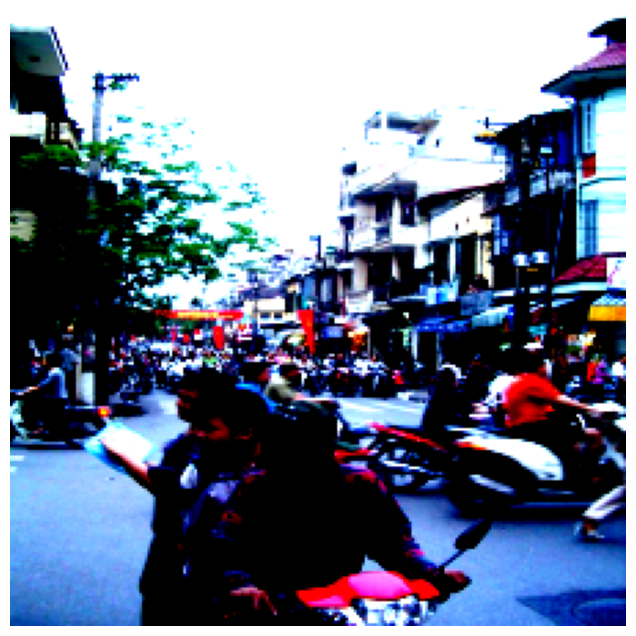

QUESTION: how many people are there
TRUE ANSWER: three oriental men are riding on a red moped scooter in the city with many people .
--------------------------------------------------
Prediction Model 1 (Base):         a man in a black shirt and a woman in a brown shirt blow bubbles with pink wands .
Prediction Model 2 (Attention):    a man in a blue shirt is kissing a woman in a white shirt on the cheek .
Prediction Model 3 (ResNet50):     a group of motorcyclist are ridding through the streets .
Prediction Model 4 (ResNet+Attn):  three young men two riding a motorbike on a busy street looking at something and smiling .


In [76]:
def compare_4_models_on_one_image(index=None):
    """Bắt cả 4 mô hình cùng trả lời cho 1 bức ảnh duy nhất."""
    if index is None:
        index = random.randint(0, len(val_dataset) - 1)

    img, ques, ans = val_dataset[index]

    ans_1 = generate_answer(model_base, img, ques, vocab, inv_vocab, device)
    ans_2 = generate_answer(model_attn, img, ques, vocab, inv_vocab, device)
    ans_3 = generate_answer(model_pretrained, img, ques, vocab, inv_vocab, device)
    ans_4 = generate_answer(model_final, img, ques, vocab, inv_vocab, device)

    true_ans = decode_sequence(ans, inv_vocab)
    question_text = decode_sequence(ques, inv_vocab)

    img_display = img.permute(1, 2, 0).cpu().numpy()


    plt.figure(figsize=(8, 8))
    plt.imshow(img_display)
    plt.axis("off")
    plt.show()

    print(f"QUESTION: {question_text}")
    print(f"TRUE ANSWER: {true_ans}")
    print("-" * 50)
    print(f"Prediction Model 1 (Base):         {ans_1}")
    print(f"Prediction Model 2 (Attention):    {ans_2}")
    print(f"Prediction Model 3 (ResNet50):     {ans_3}")
    print(f"Prediction Model 4 (ResNet+Attn):  {ans_4}")
compare_4_models_on_one_image()

# **Draw a graph comparing Validation Loss**

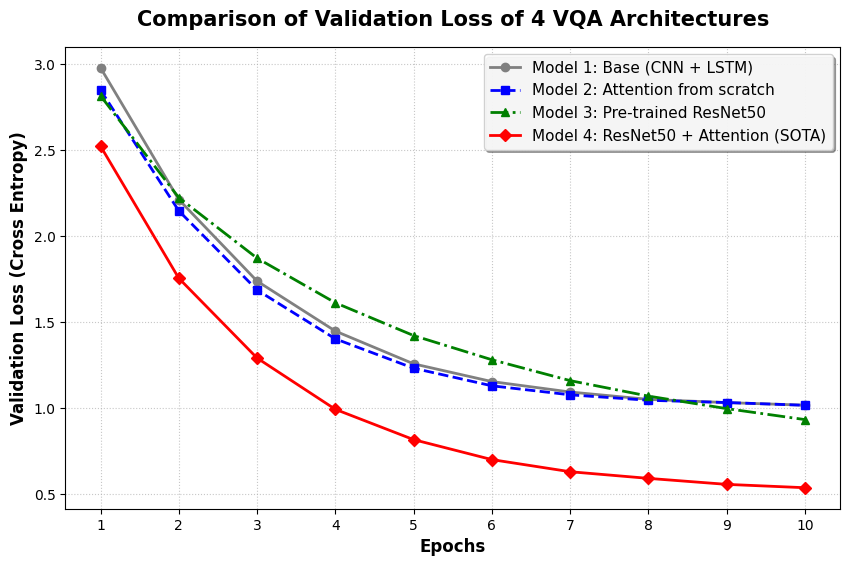

In [72]:
def plot_validation_loss_comparison(hist1, hist2, hist3, hist4, num_epochs):
    """
    Vẽ biểu đồ so sánh Validation Loss của 4 mô hình VQA.
    """
    plt.figure(figsize=(10, 6))

    epochs = range(1, num_epochs + 1)

    plt.plot(epochs, hist1['val_loss'], label='Model 1: Base (CNN + LSTM)',
             marker='o', linestyle='-', color='gray', linewidth=2)

    plt.plot(epochs, hist2['val_loss'], label='Model 2: Attention from scratch',
             marker='s', linestyle='--', color='blue', linewidth=2)

    plt.plot(epochs, hist3['val_loss'], label='Model 3: Pre-trained ResNet50',
             marker='^', linestyle='-.', color='green', linewidth=2)

    plt.plot(epochs, hist4['val_loss'], label='Model 4: ResNet50 + Attention (SOTA)',
             marker='D', linestyle='-', color='red', linewidth=2)

    plt.title('Comparison of Validation Loss of 4 VQA Architectures', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12, fontweight='bold')
    plt.ylabel('Validation Loss (Cross Entropy)', fontsize=12, fontweight='bold')

    plt.xticks(epochs)

    plt.grid(True, linestyle=':', alpha=0.7)

    plt.legend(loc='upper right', fontsize=11, framealpha=0.9, shadow=True)

    plt.savefig('vqa_validation_loss_comparison.png', dpi=300, bbox_inches='tight')

    plt.show()

EPOCHS = 10
plot_validation_loss_comparison(hist_base, hist_attn, hist_pretrained, hist_final, EPOCHS)

**1. Sức mạnh tuyệt đối của "Trùm cuối" (Đường màu đỏ)**:
* Nhìn vào đường màu đỏ (Mô hình 4: ResNet50 + Attention), ta thấy một sự vượt trội hoàn toàn.
* Nó xuất phát điểm đã thấp hơn hẳn (khoảng 2.5), chứng tỏ bộ trọng số Pre-trained ResNet50 đã cho nó một nền tảng nhận diện ảnh cực tốt.
* Tốc độ hội tụ (độ dốc của đường) cực kỳ nhanh ở 4 Epoch đầu và nhanh chóng chìm xuống mức Loss thấp nhất (~0.5) ở Epoch 10. Điều này giải thích tại sao điểm BLEU của nó lại tiệm cận mốc 30%.

**2. Sự bế tắc của việc "Học từ con số 0" (Đường xám và xanh dương)**:
* Đường màu xám (Base) và màu xanh dương (Attention from scratch) bám rất sát nhau trong suốt quá trình huấn luyện và kết thúc lơ lửng ở mức Loss > 1.0.
* Sự bám sát này là minh chứng đắt giá cho lý thuyết: "Attention không có tác dụng nếu CNN trích xuất đặc trưng kém". Dù Mô hình 2 có cơ chế tập trung thông minh, nhưng vì nó phải tự học nhận diện ảnh từ đầu (from scratch) giống Mô hình 1, nên "đôi mắt" của nó quá mờ nhạt, dẫn đến Validation Loss không thể giảm sâu thêm được.

**3. Chậm mà chắc với Transfer Learning (Đường màu xanh lá)**:
* Mô hình 3 (Pre-trained ResNet50 - Đường xanh lá) có một quỹ đạo rất thú vị.
* Ở những Epoch đầu (1 đến 4), Loss của nó thậm chí còn cao hơn cả Mô hình 1 và 2. Lý do là vì nó đang phải vất vả ghép nối phần "mắt" (ResNet50) và phần "não" (LSTM mới tinh) lại với nhau.
* Tuy nhiên, nhờ nền tảng đặc trưng ảnh cực tốt, nó học rất kiên trì (đường chéo giảm đều). Từ Epoch 8 trở đi, nó đã chính thức cắt ngang và vượt mặt Mô hình 1 & 2 để tiến về mức Loss thấp hơn.